In [42]:
import pandas as pd

pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt

import os, sys

sys.path.append(os.path.abspath(".."))

import original_data_work.helper_fn
import importlib

importlib.reload(original_data_work.helper_fn)
from original_data_work.helper_fn import load_data, get_fmc_category_only

In [2]:
df_combined_path = "../../../data/France/processed_data/combined_df.csv"
weather_data_path = "../../../data/France/processed_data/weather_till_march2.csv"
df_sellin, df_sellout = load_data(df_combined_path)
df_weather = pd.read_csv(weather_data_path)
df_weather["date"] = pd.to_datetime(df_weather["date"])

In [3]:
df_sellout = get_fmc_category_only(df_sellout)

In [4]:
df = df_sellout.merge(df_weather, on=["date", "latitude", "longitude"], how="left")

In [5]:
print(df.shape)
print(df.isna().sum())

(588131, 22)
data_type            0
source               0
date                 0
customer_code        0
customer_name      366
sku_code             0
sku_name             0
brand_variant        0
brand_name           0
category             0
sales_amount         0
sales_quantity       0
channel_name      1442
latitude           366
longitude          366
route              366
brand                0
month                0
temperature        405
precipitation      405
weathercode        405
windspeed          405
dtype: int64


In [6]:
df = df.sort_values(["latitude", "longitude", "sku_code", "date"])

df["temp_lag1"] = df.groupby(["latitude", "longitude"])["temperature"].shift(1)
df["rain_lag1"] = df.groupby(["latitude", "longitude"])["precipitation"].shift(1)

In [7]:
df["temp_3d_avg"] = df.groupby(["latitude", "longitude"])["temperature"].transform(
    lambda x: x.rolling(3).mean()
)

In [8]:
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

## EDA

In [55]:
df[["temperature", "precipitation"]].describe()

,temperature,precipitation
count,587726.000000,587726.000000
mean,7.964940,2.893599
std,3.368354,4.263942
min,-3.400000,0.000000
25%,6.200000,0.000000
50%,8.400000,0.500000
75%,10.200000,4.500000
max,29.200000,19.000000


In [53]:
df[["sales_quantity", "temperature", "precipitation"]].corr()

,sales_quantity,temperature,precipitation
sales_quantity,1.000000,0.019699,-0.007638
temperature,0.019699,1.000000,-0.033279
precipitation,-0.007638,-0.033279,1.000000


In [10]:
df.groupby(pd.cut(df["temperature"], bins=5), observed=True)["sales_quantity"].mean()

temperature
(-3.433, 3.12]    3.304940
(3.12, 9.64]      3.629794
(9.64, 16.16]     3.650104
(22.68, 29.2]     3.738342
Name: sales_quantity, dtype: float64

In [11]:
# Rain vs No Rain comparison
df.groupby(df["precipitation"] > 0)["sales_quantity"].mean()

precipitation
False    3.610132
True     3.607674
Name: sales_quantity, dtype: float64

### Forecasting with Temp Data

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ["temperature", "precipitation", "windspeed", "day_of_week", "month"]

X = df[features]
y = df["sales_quantity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
importance = pd.DataFrame(
    {"feature": features, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)

print(importance)

         feature  importance
2      windspeed    0.352207
0    temperature    0.314766
1  precipitation    0.180930
3    day_of_week    0.132297
4          month    0.019801


## SKU LEVEL Analysis

In [14]:
df.groupby(["customer_code", "sku_code", "date"])["sales_quantity"].sum()

customer_code       sku_code            date      
0011t000011b1GgAAI  a0U1t000002PXjhEAG  2026-01-09    1.0
                                        2026-01-10    1.0
                                        2026-01-19    1.0
                                        2026-01-21    1.0
                                        2026-01-24    1.0
                                                     ... 
a0f1t000002XqBDAA0  a0U3W000002BYaXUAW  2026-03-26    4.0
                                        2026-03-27    1.0
                                        2026-03-28    3.0
                                        2026-03-30    4.0
                                        2026-03-31    1.0
Name: sales_quantity, Length: 587420, dtype: float64

In [15]:
df["temp_lag1"] = df.groupby(["customer_code", "sku_code"])["temperature"].shift(1)
df["temp_lag2"] = df.groupby(["customer_code", "sku_code"])["temperature"].shift(2)
df["temp_lag3"] = df.groupby(["customer_code", "sku_code"])["temperature"].shift(3)

In [16]:
df["rain_lag1"] = df.groupby(["customer_code", "sku_code"])["precipitation"].shift(1)
df["rain_lag2"] = df.groupby(["customer_code", "sku_code"])["precipitation"].shift(2)

In [17]:
df["wind_lag1"] = df.groupby(["customer_code", "sku_code"])["windspeed"].shift(1)

In [18]:
# Overall Corelation.

cols = [
    "sales_quantity",
    "temperature",
    "temp_lag1",
    "temp_lag2",
    "precipitation",
    "rain_lag1",
    "rain_lag2",
    "windspeed",
    "wind_lag1",
]

df[cols].corr()["sales_quantity"]

sales_quantity    1.000000
temperature       0.019699
temp_lag1         0.017982
temp_lag2         0.013648
precipitation    -0.007638
rain_lag1         0.004061
rain_lag2         0.006250
windspeed        -0.003279
wind_lag1         0.002961
Name: sales_quantity, dtype: float64

In [19]:
# for shop in df["customer_code"].unique():
#     temp = df[df["customer_code"] == shop]

#     print(shop, temp["temperature"].corr(temp["sales_quantity"]))

result = df.groupby(["customer_code", "sku_code"]).apply(
    lambda x: x["temperature"].corr(x["sales_quantity"])
)

result = result.reset_index()
result.sort_values(0, ascending=False).head()

/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_7505/654964386.py:6: DeprecationWarning: DataFram

,customer_code,sku_code,0
1106,0011t000011b1TlAAI,a0U1t000002PXpUEAW,1.0
7960,0011t000011b4ToAAI,a0U1t000002PXqGEAW,1.0
6047,0011t000011b39tAAA,a0U1t000002PXpcEAG,1.0
3185,0011t000011b2AhAAI,a0U1t000002PXpKEAW,1.0
10057,0011t000011b59fAAA,a0U1t000002PXqGEAW,1.0


In [ ]:
df_filtered = df[
    (df["customer_code"] == "0011t000011b5TiAAI")
    & (df["sku_code"] == "a0U1t000002PXlqEAG")
]

weather_cols = [
    "temperature",
    "temp_lag1",
    "temp_lag2",
    "precipitation",
    "rain_lag1",
    "rain_lag2",
    "windspeed",
    "wind_lag1",
]

target = "sales_quantity"

df_filtered[[target] + weather_cols].corr("spearman")[target]

sales_quantity    1.000000
temperature       0.011543
temp_lag1         0.130631
temp_lag2         0.138017
precipitation    -0.181403
rain_lag1         0.059170
rain_lag2         0.142337
windspeed        -0.122689
wind_lag1         0.102710
Name: sales_quantity, dtype: float64

## Using ML to find out any relation

In [21]:
shop_id = "0011t000011b5TiAAI"
sku_id = "a0U1t000002PXlqEAG"
df_sku = df[(df["customer_code"] == shop_id) & (df["sku_code"] == sku_id)].copy()

In [22]:
df_sku = df_sku.sort_values("date")

In [23]:
df_sku["temp_lag1"] = df_sku["temperature"].shift(1)
df_sku["temp_lag2"] = df_sku["temperature"].shift(2)

df_sku["rain_lag1"] = df_sku["precipitation"].shift(1)
df_sku["rain_lag2"] = df_sku["precipitation"].shift(2)

In [24]:
df_sku["date"] = pd.to_datetime(df_sku["date"])

df_sku["day_of_week"] = df_sku["date"].dt.dayofweek
df_sku["month"] = df_sku["date"].dt.month

In [25]:
df_sku = df_sku.dropna()

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [27]:
features = [
    "temperature",
    "precipitation",
    # "windspeed",
    "temp_lag1",
    "temp_lag2",
    "rain_lag1",
    "rain_lag2",
    # "day_of_week",
    # "month",
]

X = df_sku[features]
y = df_sku["sales_quantity"]

In [28]:
split = int(len(df_sku) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [29]:
model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 8.558055555555555


In [31]:
imp = pd.DataFrame(
    {"feature": features, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)

print(imp)

         feature  importance
2      temp_lag1    0.275253
5      rain_lag2    0.186321
3      temp_lag2    0.172343
0    temperature    0.170651
1  precipitation    0.117334
4      rain_lag1    0.078098


## Top 1000 Customer Analysis

In [64]:
df["is_rain"] = df["precipitation"] >= 2
df["is_rain_lag1"] = df["rain_lag1"] >= 2
df["is_rain_lag2"] = df["rain_lag2"] >= 2

In [48]:
df_event_with_holiday_path = (
    "../../../data/France/processed_data/df_events_with_holidays_all.csv"
)
df_spikes = pd.read_csv(df_event_with_holiday_path, low_memory=False)

In [65]:
# Check all 10 quantiles
df[["temperature", "precipitation"]].describe()

,temperature,precipitation
count,587726.000000,587726.000000
mean,7.964940,2.893599
std,3.368354,4.263942
min,-3.400000,0.000000
25%,6.200000,0.000000
50%,8.400000,0.500000
75%,10.200000,4.500000
max,29.200000,19.000000


In [117]:
print("98th Quartile Value for Temperature is: ", df.temperature.quantile(0.98))

98th Quartile Value for Temperature is:  12.6


In [119]:
cols = [
    "sales_quantity",
    "temperature",
    "temp_lag1",
    "temp_lag2",
    # "precipitation",
    # "rain_lag1",
    # "rain_lag2",
    "is_rain",
    "is_rain_lag1",
    "is_rain_lag2",
]

df[cols].corr()["sales_quantity"].drop("sales_quantity")

temperature     0.019699
temp_lag1       0.017982
temp_lag2       0.013648
is_rain        -0.006507
is_rain_lag1    0.009019
is_rain_lag2    0.011473
Name: sales_quantity, dtype: float64

In [91]:
top_200_customers = df.groupby("customer_code")["sales_quantity"].sum().nlargest(100)

top_200_customers = top_200_customers.index.to_list()

In [96]:
result = []

weather_cols = [
    "temperature",
    "temp_lag1",
    "temp_lag2",
    "precipitation",
    "rain_lag1",
    "rain_lag2",
    "is_rain",
    "is_rain_lag1",
    "is_rain_lag2",
]

target = "sales_quantity"

toal = 1000
cur = 0

for customer in top_200_customers:

    top_10_skus = (
        df[df["customer_code"] == customer]["sku_code"]
        .value_counts()
        .nlargest(10)
        .index.to_list()
    )

    for sku in top_10_skus:
        print(f"{cur}/{total}")
        cur += 1

        df_group = df[(df["customer_code"] == customer) & (df["sku_code"] == sku)]

        # skip small/noisy groups
        if len(df_group) < 10:
            continue

        cols = weather_cols + [target]

        # ensure no constant columns
        df_group = df_group[cols].loc[:, df_group[cols].nunique() > 1]

        try:
            pearson = df_group.corr()[target].drop(target)
            spearman = df_group.corr(method="spearman")[target].drop(target)
            kendall = df_group.corr(method="kendall")[target].drop(target)

            result.append(
                {
                    "customer_code": customer,
                    "sku_code": sku,
                    "pearson": pearson.to_dict(),
                    "spearman": spearman.to_dict(),
                    "kendall": kendall.to_dict(),
                }
            )

        except Exception:
            continue

0/1000
1/1000
2/1000
3/1000
4/1000
5/1000
6/1000
7/1000
8/1000
9/1000
10/1000
11/1000
12/1000
13/1000
14/1000
15/1000
16/1000
17/1000
18/1000
19/1000
20/1000
21/1000
22/1000
23/1000
24/1000
25/1000
26/1000
27/1000
28/1000
29/1000
30/1000
31/1000
32/1000
33/1000
34/1000
35/1000
36/1000
37/1000
38/1000
39/1000
40/1000
41/1000
42/1000
43/1000
44/1000
45/1000
46/1000
47/1000
48/1000
49/1000
50/1000
51/1000
52/1000
53/1000
54/1000
55/1000
56/1000
57/1000
58/1000
59/1000
60/1000
61/1000
62/1000
63/1000
64/1000
65/1000
66/1000
67/1000
68/1000
69/1000
70/1000
71/1000
72/1000
73/1000
74/1000
75/1000
76/1000
77/1000
78/1000
79/1000
80/1000
81/1000
82/1000
83/1000
84/1000
85/1000
86/1000
87/1000
88/1000
89/1000
90/1000
91/1000
92/1000
93/1000
94/1000
95/1000
96/1000
97/1000
98/1000
99/1000
100/1000
101/1000
102/1000
103/1000
104/1000
105/1000
106/1000
107/1000
108/1000
109/1000
110/1000
111/1000
112/1000
113/1000
114/1000
115/1000
116/1000
117/1000
118/1000
119/1000
120/1000
121/1000
122/1000
123

In [98]:
result = pd.DataFrame(result)

In [101]:
rows = []

for _, row in result.iterrows():
    for feature, value in row["pearson"].items():
        rows.append(
            {
                "customer_code": row["customer_code"],
                "sku_code": row["sku_code"],
                "feature": feature,
                "pearson": value,
                "spearman": row["spearman"].get(feature),
                "kendall": row["kendall"].get(feature),
            }
        )

df_long = pd.DataFrame(rows)

In [120]:
features = [
    "temperature",
    "temp_lag1",
    "temp_lag2",
    "is_rain",
    "is_rain_lag1",
    "is_rain_lag2",
]

df_sel = df_long[df_long["feature"].isin(features)]

In [130]:
summary = pd.concat(
    {
        "pearson": df_sel.groupby("feature")["pearson"].describe(),
        "spearman": df_sel.groupby("feature")["spearman"].describe(),
        "kendall": df_sel.groupby("feature")["kendall"].describe(),
    },
    axis=1,
)

In [131]:
summary

pearson                                                    \
               count      mean       std       min       25%       50%   
feature                                                                  
is_rain       1000.0 -0.019130  0.121210 -0.444867 -0.102763 -0.025068   
is_rain_lag1  1000.0  0.020230  0.115193 -0.366431 -0.059071  0.021964   
is_rain_lag2  1000.0  0.006613  0.114701 -0.344743 -0.072570  0.005530   
temp_lag1     1000.0  0.045370  0.128795 -0.465403 -0.037042  0.051662   
temp_lag2     1000.0  0.032509  0.125860 -0.418227 -0.051210  0.038821   
temperature   1000.0  0.044226  0.126671 -0.440925 -0.040385  0.051077   

                                 spearman                                \
                   75%       max    count      mean       std       min   
feature                                                                   
is_rain       0.068451  0.401358   1000.0 -0.019086  0.122502 -0.578889   
is_rain_lag1  0.097823  0.491670   1000.0  0.023643  0.117582 -0.372886   
is_rain_lag2  0.083734  0.380475   1000.0  0.009602  0.114201 -0.417938   
temp_lag1     0.133463  0.405576   1000.0  0.038567  0.131030 -0.421612   
temp_lag2     0.115002  0.398900   1000.0  0.030371  0.131946 -0.470771   
temperature   0.129886  0.420829   1000.0  0.034287  0.129711 -0.355403   

                                                     kendall            \
                   25%       50%       75%       max   count      mean   
feature                                                                  
is_rain      -0.105431 -0.020767  0.064944  0.471331  1000.0 -0.016550   
is_rain_lag1 -0.054515  0.024832  0.106361  0.501835  1000.0  0.020615   
is_rain_lag2 -0.066690  0.008709  0.085137  0.383021  1000.0  0.008247   
temp_lag1    -0.048497  0.039942  0.122771  0.460382  1000.0  0.027518   
temp_lag2    -0.050595  0.025876  0.118534  0.403849  1000.0  0.021604   
temperature  -0.051116  0.035401  0.118896  0.448313  1000.0  0.024169   

                                                                          
                   std       min       25%       50%       75%       max  
feature                                                                   
is_rain       0.107733 -0.543666 -0.092295 -0.018387  0.058066  0.426374  
is_rain_lag1  0.103595 -0.323198 -0.048578  0.021738  0.093178  0.472144  
is_rain_lag2  0.100692 -0.390632 -0.057992  0.007649  0.074763  0.355902  
temp_lag1     0.094911 -0.317227 -0.034498  0.027874  0.089353  0.329490  
temp_lag2     0.095662 -0.339386 -0.037516  0.019230  0.085261  0.288800  
temperature   0.093695 -0.271909 -0.035903  0.024153  0.085823  0.313542

## Check Sales on Day or After Rain

In [224]:
# Consider only the rain that is > 4mm, which keep people indoor.
df["is_rain"] = df["precipitation"] >= 10
df["is_rain_lag1"] = df["is_rain"].shift(1)
df["is_rain_lag2"] = df["is_rain"].shift(2)

In [225]:
# Load spikes dataframe.
df_spikes_path = "../../../data/France/processed_data/df_events_with_holidays_all.csv"
df_spikes = pd.read_csv(df_spikes_path, low_memory=False)

In [226]:
df.is_rain.value_counts()

is_rain
False    542811
True      45320
Name: count, dtype: int64

In [227]:
# STEP 1: Aggregate to daily level (per customer)
df_daily = (
    df.groupby(["customer_code", "date"])
    .agg({"sales_quantity": "sum", "is_rain": "max"})
    .reset_index()
)

# STEP 2: Sort properly
df_daily = df_daily.sort_values(["customer_code", "date"])

# STEP 3: Apply shift PER CUSTOMER
df_daily["sales_-1"] = df_daily.groupby("customer_code")["sales_quantity"].shift(1)
df_daily["sales_-2"] = df_daily.groupby("customer_code")["sales_quantity"].shift(2)
df_daily["sales_-3"] = df_daily.groupby("customer_code")["sales_quantity"].shift(3)

df_daily["sales_+1"] = df_daily.groupby("customer_code")["sales_quantity"].shift(-1)
df_daily["sales_+2"] = df_daily.groupby("customer_code")["sales_quantity"].shift(-2)
df_daily["sales_+3"] = df_daily.groupby("customer_code")["sales_quantity"].shift(-3)

In [228]:
df_rain = df_daily[df_daily["is_rain"] == 1].copy()

df_rain_analysis = df_rain[
    [
        "customer_code",
        "date",
        "sales_-1",
        "sales_-2",
        "sales_-3",
        "sales_quantity",
        "sales_+1",
        "sales_+2",
    ]
].copy()

df_rain_analysis = df_rain_analysis.rename(
    columns={
        "sales_-3": "3_days_before",
        "sales_-2": "2_days_before",
        "sales_-1": "1_day_before",
        "sales_quantity": "rain_day",
        "sales_+1": "1_day_after",
        "sales_+2": "2_days_after",
    }
)

In [229]:
pattern = df_rain_analysis[
    [
        "3_days_before",
        "2_days_before",
        "1_day_before",
        "rain_day",
        "1_day_after",
        "2_days_after",
    ]
].mean()

print(pattern)

3_days_before    43.672079
2_days_before    42.532198
1_day_before     43.864290
rain_day         42.292975
1_day_after      44.440128
2_days_after     45.883418
dtype: float64


In [230]:
pattern_normalized = pattern / pattern["rain_day"]
print(pattern_normalized)

3_days_before    1.032608
2_days_before    1.005656
1_day_before     1.037153
rain_day         1.000000
1_day_after      1.050769
2_days_after     1.084895
dtype: float64


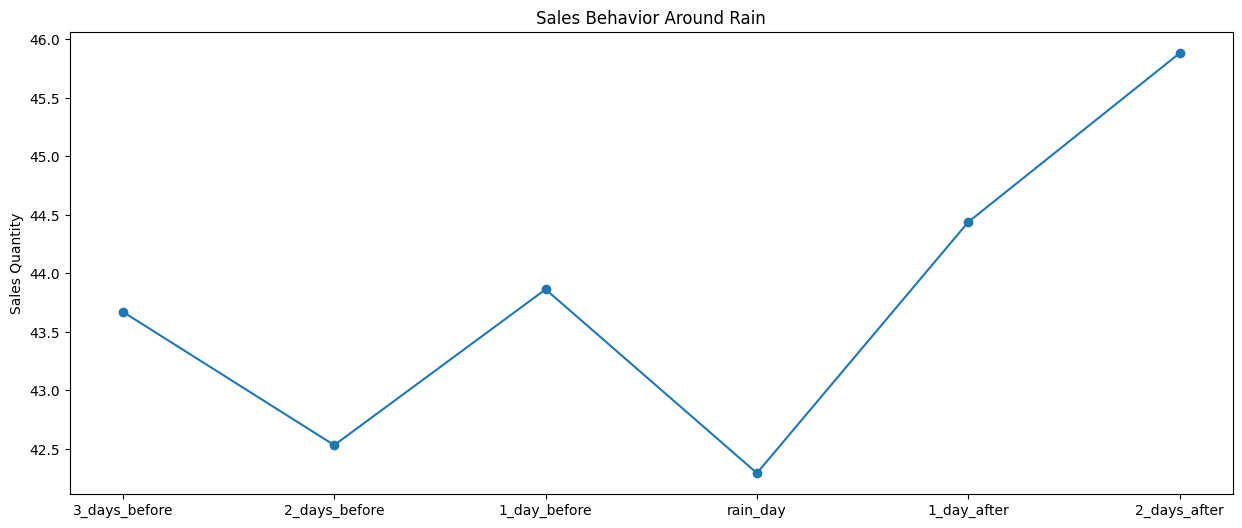

In [231]:
plt.figure(figsize=(15, 6))
pattern.plot(marker="o")
plt.title("Sales Behavior Around Rain")
plt.ylabel("Sales Quantity")
plt.show()

In [232]:
# Super set (Shop visits) # Check in these. # Must be decline and then hit 0 and didn't rise up.

## Extra

In [241]:
df_sellin, df_sellout = load_data(df_combined_path)

In [245]:
df_sellout[
    (df_sellout["customer_name"] == 300005.0)
    & (df_sellout["sku_name"] == "86196 - VELO ICE ALASKA 11MG")
]

,data_type,source,date,customer_code,customer_name,sku_code,sku_name,brand_variant,brand_name,category,sales_amount,sales_quantity,channel_name,latitude,longitude,route,brand,month
546686,sell_out,Logista,2026-02-01,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,1,1.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
550164,sell_out,Logista,2026-02-03,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,1,1.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
552284,sell_out,Logista,2026-02-04,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,1,1.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
554462,sell_out,Logista,2026-02-05,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,5,5.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
556694,sell_out,Logista,2026-02-06,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,3,3.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
559149,sell_out,Logista,2026-02-07,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,1,1.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
561345,sell_out,Logista,2026-02-08,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,3,3.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
562587,sell_out,Logista,2026-02-09,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,4,4.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
568883,sell_out,Logista,2026-02-12,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,3,3.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02
573369,sell_out,Logista,2026-02-14,0011t000011b5TiAAI,300005.0,a0U3W000002A7QtUAK,86196 - VELO ICE ALASKA 11MG,FR_BV_86196 - VELO ICE ALASKA 11MG,FR_BF_VELO,Oral,3,3.0,COCO,48.88338,2.32791,a0D1t000005iLAnEAM,VELO,2026-02


In [243]:
# Shop 300005.0 86196
df_sellout[df_sellout["customer_name"] == 300005.0]["sku_name"].unique()

array(['47762 - PALL MALL EN 30G', nan,
       '87055 - LUCKY STRIKE RED 30G 6 LM',
       '87056 - LUCKY STRIKE ORIGINAL 30G 6 LM',
       '125 - LUCKY STRIKE RED 20', '862 - PETER STUYVESANT BLEU EN 20',
       '1201 - LUCKY STRIKE BLEU EN 20',
       '2520 - DUNHILL INTERNATIONAL ROUGE EN 20',
       '2590 - DUNHILL ROUGE EN 20', '3010 - ROTHMANS ROUGE EN 20',
       '3721 - VOGUE ORIGINALE BLEUE EN 20', '4815 - DUNHILL BLEU EN 20',
       '6414 - VOGUE ORIGINALE PASTEL EN 20',
       '60664 - LUCKY STRIKE RED 25', '61434 - LUCKY STRIKE RED 30',
       '85162 - VOGUE GOLD EN 20', '85541 - LUCKY STRIKE X SERIES EN 20',
       '85545 - LUCKY STRIKE BLEU LONGUES',
       '85548 - VOGUE Lâ€™ORIGINALE VERTE ICE 20s',
       '85551 - LUCKY STRIKE ICE 20s', '1562 - ROTHMANS BLEU EN 20',
       '3253 - PETER STUYVESANT ARGENT EN 20',
       '60690 - ROTHMANS BLEU EN 25',
       '61386 - ROTHMANS BLEU LONGUES EN 20',
       '83080 - LUCKY STRIKE ORIGINAL TABAC BRESIL EN 20',
       '83135 - 

In [ ]:
# Sellout data is missing for other categories in Jan except FMC (Oral, Vapour Liquid, Vapour Devices).
# Although the sellin data is present in Jan, but no sellout data.